In [4]:
import sys
import os
sys.path.append('../')

import skimage
import microdet.mnds
import numpy as np

In [3]:
im1 = skimage.io.imread('/scr/yren/dataset_v3_all/C1-20X_c0_B3_Tile-15.phenotype.tif')
im2 = skimage.io.imread('/scr/yren/dataset_v3_all/C1-20X_c0_B3_Tile-15.phenotype_outlines.png')

In [4]:
print(im1.shape)
print(im2.shape)

(2720, 2720)
(2720, 2720, 4)


In [5]:
im3 = skimage.transform.rescale(im2, 1.07, channel_axis=2)
print(im3.shape)

(2910, 2910, 4)


In [3]:
path = '/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/'
files = [f for f in os.listdir(path) if os.path.isfile(path + '/' + f)]
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

print(len(annot_files))
annot_files

24


['20X_c0-DAPI_A1_Tile-10.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-110.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-130.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-150.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-170.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-30.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-50.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-70.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-90.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-15.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-24.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-5.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-18.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-44.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype_outlines.png',
 'C2-2

In [6]:
annot_files[13]

'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png'

- training set

In [ ]:
i = 13
training_files = annot_files.copy()
validation_files = [annot_files[i]]
del training_files[i]
training_files = annot_files
training_set = microdet.mnds.MicronucleiDataset(
                filelist=training_files, 
                directory='/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/', 
                mode="random",
                edges=True,
                transform=microdet.mnds.detection_transforms,
                scale_factor=1,
                patch_size=256,
                gaussian=True,
                annotation_type='edge'
            )

100%|██████████| 44/44 [01:20<00:00,  1.82s/it]

2022-03-18_RPE1-3: height - 768, width - 869, patches - 9
2022-03-18_RPE1-4: height - 768, width - 869, patches - 9
2022-03-18_RPE1-5: height - 768, width - 869, patches - 9
2022-04-14_RPE1-2: height - 768, width - 869, patches - 9
2022-04-14_RPE1-2198: height - 768, width - 869, patches - 9
2022-04-14_RPE1-5: height - 768, width - 869, patches - 9
2022-05-25_RPE1-1: height - 768, width - 869, patches - 9
2022-05-25_RPE1-2: height - 768, width - 869, patches - 9
2022-05-25_RPE1-3: height - 768, width - 869, patches - 9
2022-05-26_RPE1-1: height - 768, width - 869, patches - 9
2022-05-26_RPE1-2: height - 768, width - 869, patches - 9
2022-05-26_RPE1-2198: height - 768, width - 869, patches - 9
2022-05-27_RPE1-1: height - 768, width - 869, patches - 9
2022-05-27_RPE1-2197: height - 768, width - 869, patches - 9
2022-05-27_RPE1-3: height - 768, width - 869, patches - 9
2022-10-14_U2OS-1: height - 768, width - 869, patches - 9
2022-10-14_U2OS-10: height - 768, width - 869, patches - 9
2022


/scr/yren/micronuclei-detection/microdet/mnds.py:151: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.all_locs = pd.concat(all_locs)


- validation set

In [ ]:
validation_set = microdet.mnds.MicronucleiDataset(
    filelist=validation_files, 
    directory='/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/', 
    mode="fixed",
    edges=True,
    scale_factor=1,
    patch_size=256,
    gaussian=True,
    annotation_type='edge'
)

100%|██████████| 1/1 [00:00<00:00, 16.74it/s]

2022-05-27_RPE1-2197: height - 768, width - 869
2022-05-27_RPE1-2197: height - 768, width - 869, patches - 9


In [ ]:
from tqdm import tqdm
import pandas as pd

annotation_type = 'edge'
scale_factor = 1
directory = '/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/'
# directory = '/scr/yren/dataset_v2'
files = [f for f in os.listdir(directory) if os.path.isfile(directory + '/' + f)]
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
filelist = [x for x in filelist if x.endswith('png')]
filelist.sort()

all_locs = []
images = {}
for fname in tqdm(filelist):
    imid = fname.split('.')[0]
    im = mnds.read_image(directory, imid, 'phenotype.tif', scale_factor)
    im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
    mni = mnds.read_micronuclei_annotations(directory, imid, annotation_type=annotation_type)
    mnm = mnds.read_micronuclei_masks(directory, imid, annotation_type=annotation_type)
    nuc = mnds.read_nuclei_masks(directory, imid)
    all_locs.append(mni)
    images[imid] = {"image":im, "micro":mnm, "nuclei":nuc, "loc":mni}
    
all_locs = pd.concat(all_locs)

# Validate image sizes
S = np.asarray([images[imid]["image"].shape for imid in images.keys()])
S

In [ ]:
S[:,0]

In [ ]:
np.mean(S[:,0])

# Save the example data & Check False Positives

In [9]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Add the parent directory to the path for module imports
sys.path.append('../')

# Import specific modules from microdet
from microdet import mnmodel
from microdet import mnds
from microdet import evaluation
import skimage

In [3]:
path = '/scr/yren/micronuclei-detection/microdet/scale_aligned_dataset_v2_v3/'
files = [f for f in os.listdir(path) if os.path.isfile(path + '/' + f)]
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

print(len(annot_files))
annot_files[13]

24


'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png'

In [5]:
im = skimage.io.imread(path + annot_files[13])
print(im.shape)

(2910, 2910, 4)


In [3]:
CURRENT_PATH = '/scr/yren/micronuclei-detection/microdet'
DIRECTORY = CURRENT_PATH + '/scale_aligned_dataset_v2_v3'
OUTPUT_DIR = "/model_output/output/"

ANNOTATION_TYPE = 'edge'
PATCH_SIZE = 256
THRESHOLD = 0.5
SCALE_FACTOR = 1.0 # images have been prescaled already
STEP = 16
BATCH_SIZE = 32
DILATION = 2

predictions_dir = DIRECTORY + OUTPUT_DIR
models_dir = OUTPUT_DIR
device = f"cuda:3" if torch.cuda.is_available() else 'cpu'

In [12]:
validation_file = annot_files[13]
imid = validation_file.split('.')[0]

# Load image and annotations
im = mnds.read_image(DIRECTORY, imid, 'phenotype.tif', scale=SCALE_FACTOR)
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)

# Load model and compute probabilities
model = mnmodel.MicronucleiModel(
    DIRECTORY, 
    device, 
    annotation_type=ANNOTATION_TYPE,
    patch_size=PATCH_SIZE, 
    edges=True, 
    gaussian=False # predict() function has nothing to do with gaussian sampling
)
model.load(validation_file.replace('phenotype_outlines.png','pth'), model_dir=models_dir)
probabilities = model.predict(im, stride=1, step=STEP, batch_size=BATCH_SIZE, dilation=DILATION)
filename = predictions_dir + validation_file.replace('phenotype_outlines.png','_probabilities')
np.save(filename, probabilities)

mn_pred = probabilities[0,:,:] > THRESHOLD
evaluation.segmentation_report(imid=imid, predictions=mn_pred, gt=mn_gt, intersection_ratio=0.1, report_obj='Micronuclei')

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
100%|██████████| 166/166 [04:19<00:00,  1.56s/it]
/scr/yren/micronuclei-detection/notebooks/../microdet/mnmodel.py:398: RuntimeWarning: invalid value encountered in divide
  probabilities = probabilities/counts


C1-20X_c0_phalloidin_C3_Tile-15,0.7100,0.9342


Error: You must call wandb.init() before wandb.log()

In [13]:
annot_files[13]

'C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png'

In [4]:
prob = np.load(DIRECTORY + '/model_output/output/C1-20X_c0_phalloidin_C3_Tile-15._probabilities.npy')
print(prob.shape)

(2, 2910, 2910)


- micronuclei prediction

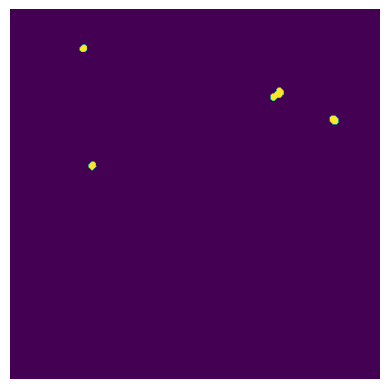

In [26]:
mn_pred = prob[0,:,:] > THRESHOLD
plt.imshow(mn_pred[1500:2000, 1500:2000])
plt.grid(False)
plt.axis('off')
plt.show()

- raw input

(2910, 2910)


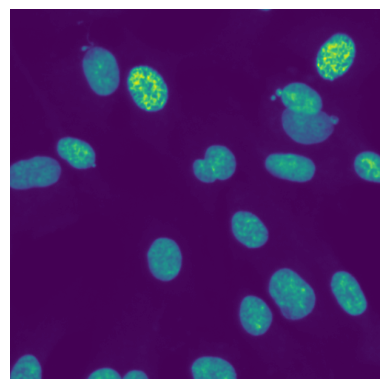

In [25]:
filename = '/scr/yren/scale_aligned_dataset_v2_v3/C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif'
im = skimage.io.imread(filename)
print(im.shape)
plt.imshow(im[1500:2000, 1500:2000])
plt.grid(False)
plt.axis('off')
plt.show()

- nuclei prediction

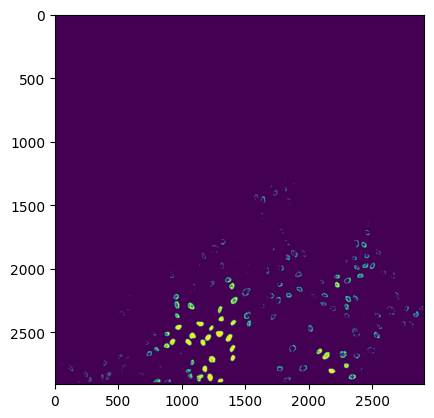

In [15]:
plt.imshow(prob[1,:,:] > THRESHOLD)

In [16]:
np.unique(prob[1,:,:])

array([0.        , 0.00390625, 0.00416667, ..., 0.99609375, 1.        ,
              nan], dtype=float32)

(2910, 2910, 4)


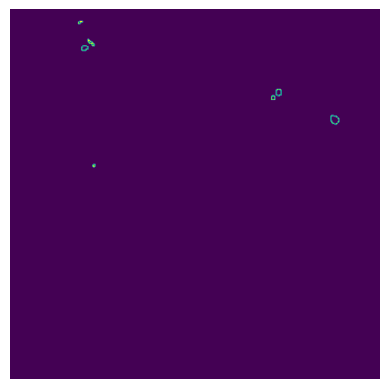

In [24]:
im = skimage.io.imread('/scr/yren/scale_aligned_dataset_v2_v3/C1-20X_c0_phalloidin_C3_Tile-15.phenotype_outlines.png')
print(im.shape)
plt.imshow(im[1500:2000,1500:2000,0])
plt.grid(False)
plt.axis('off')
plt.show()

In [21]:
mn_pred = prob[0,:,:] > THRESHOLD
mn_labels = skimage.measure.label(mn_pred)
print(np.unique(mn_labels))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98]


In [22]:
import matplotlib.pyplot as plt

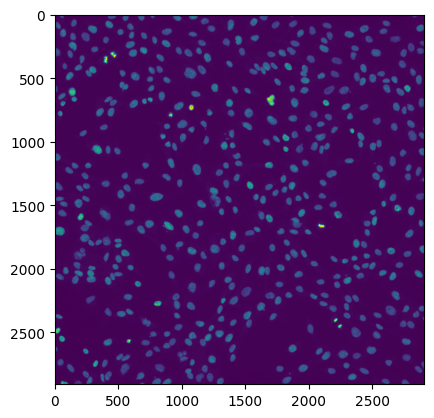

In [27]:
plt.imshow(im)

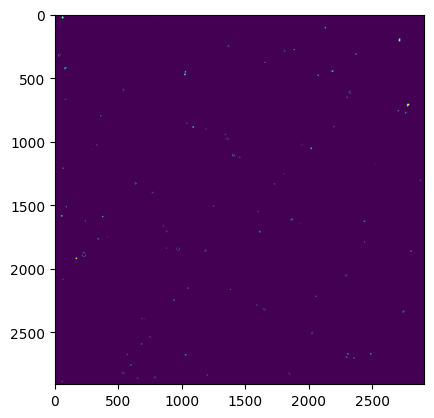

In [46]:
plt.imshow(mn_pred & ~mn_gt) # check the false positives, where True in predictions and True in background (originally False, so need NOT operation)

- Example 1

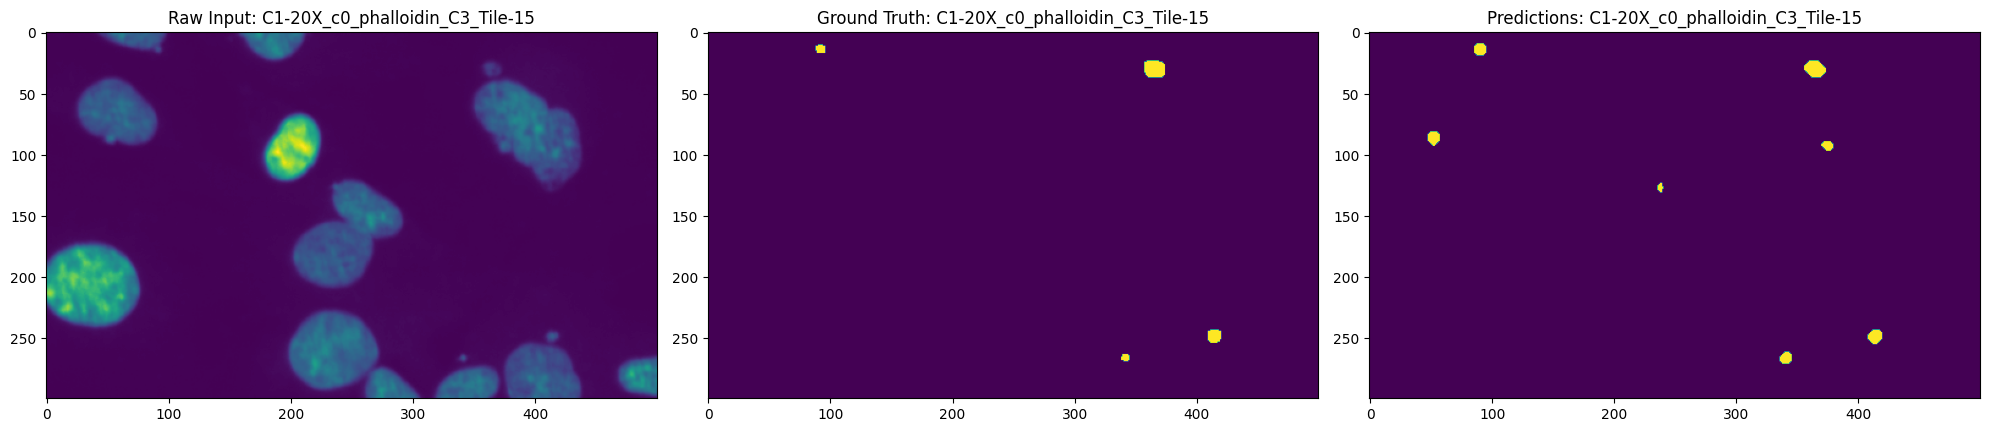

In [55]:
fig, ax = plt.subplots(1,3,figsize=(20,20))

row_start = 1500
row_end = 1800
column_start = 0
column_end = 500


ax[0].imshow(im[row_start:row_end, column_start:column_end])
ax[0].set_title(f'Raw Input: {imid}')

ax[1].imshow(mn_gt[row_start:row_end, column_start:column_end])
ax[1].set_title(f'Ground Truth: {imid}')

ax[2].imshow(mn_pred[row_start:row_end, column_start:column_end])
ax[2].set_title(f'Predictions: {imid}')

plt.tight_layout()
plt.show()

- Example 2

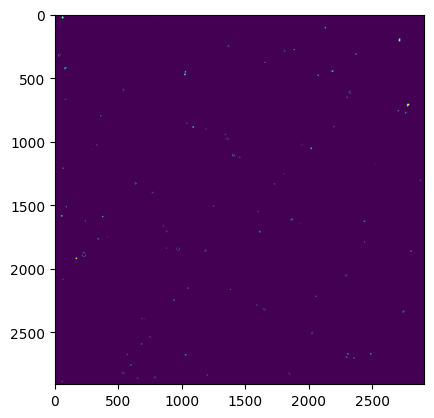

In [56]:
plt.imshow(mn_pred & ~mn_gt) # check the false positives, where True in predictions and True in background (originally False, so need NOT operation)

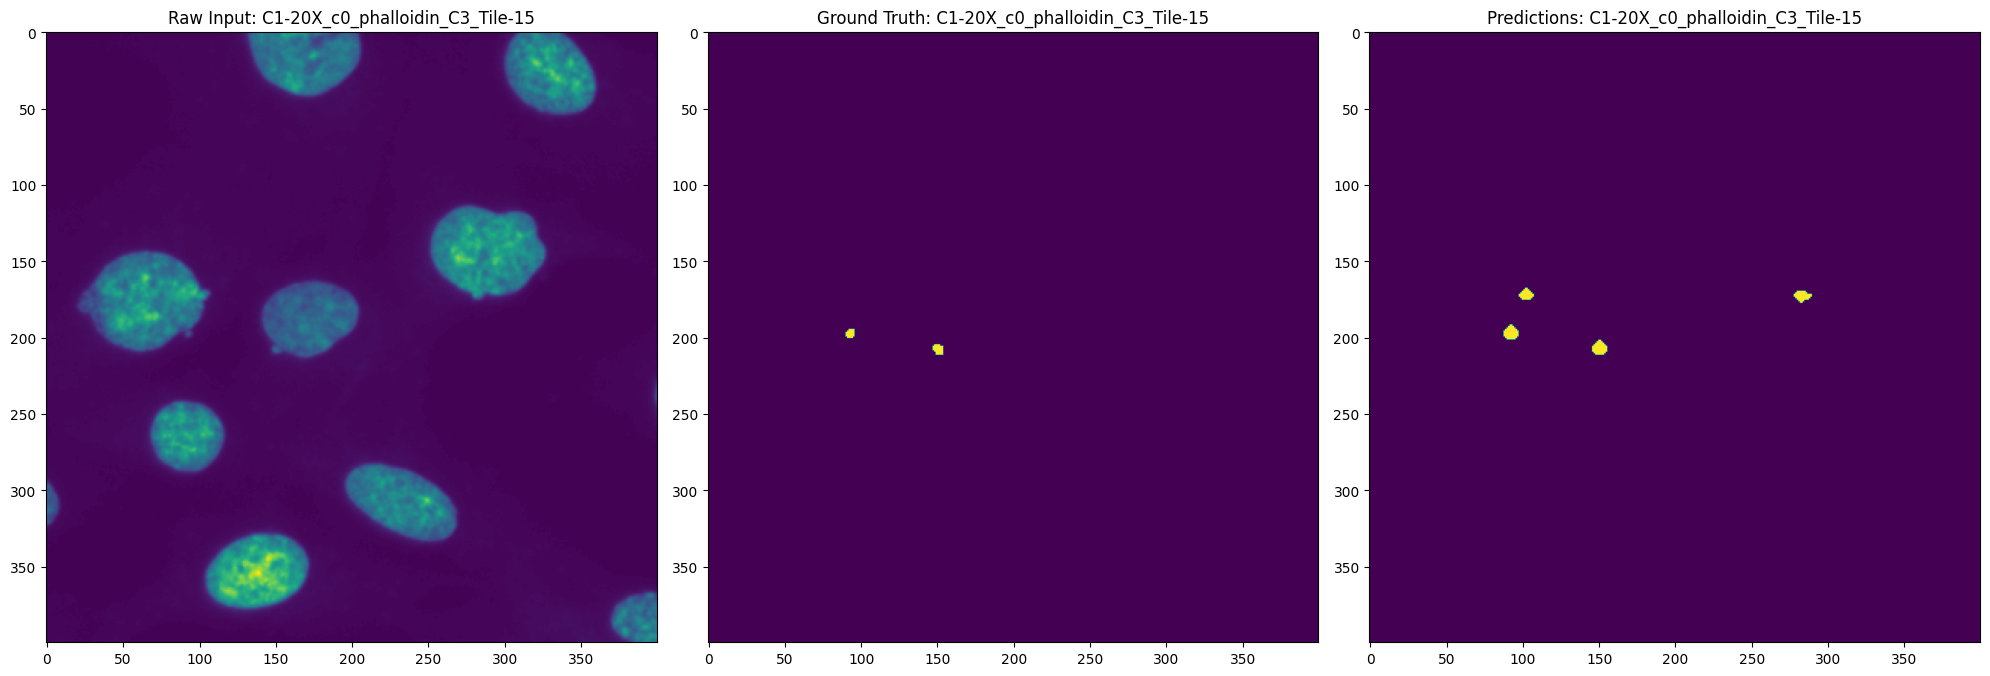

In [57]:
fig, ax = plt.subplots(1,3,figsize=(20,20))

row_start = 2500
row_end = 2900
column_start = 2200
column_end = 2600


ax[0].imshow(im[row_start:row_end, column_start:column_end])
ax[0].set_title(f'Raw Input: {imid}')

ax[1].imshow(mn_gt[row_start:row_end, column_start:column_end])
ax[1].set_title(f'Ground Truth: {imid}')

ax[2].imshow(mn_pred[row_start:row_end, column_start:column_end])
ax[2].set_title(f'Predictions: {imid}')

plt.tight_layout()
plt.show()

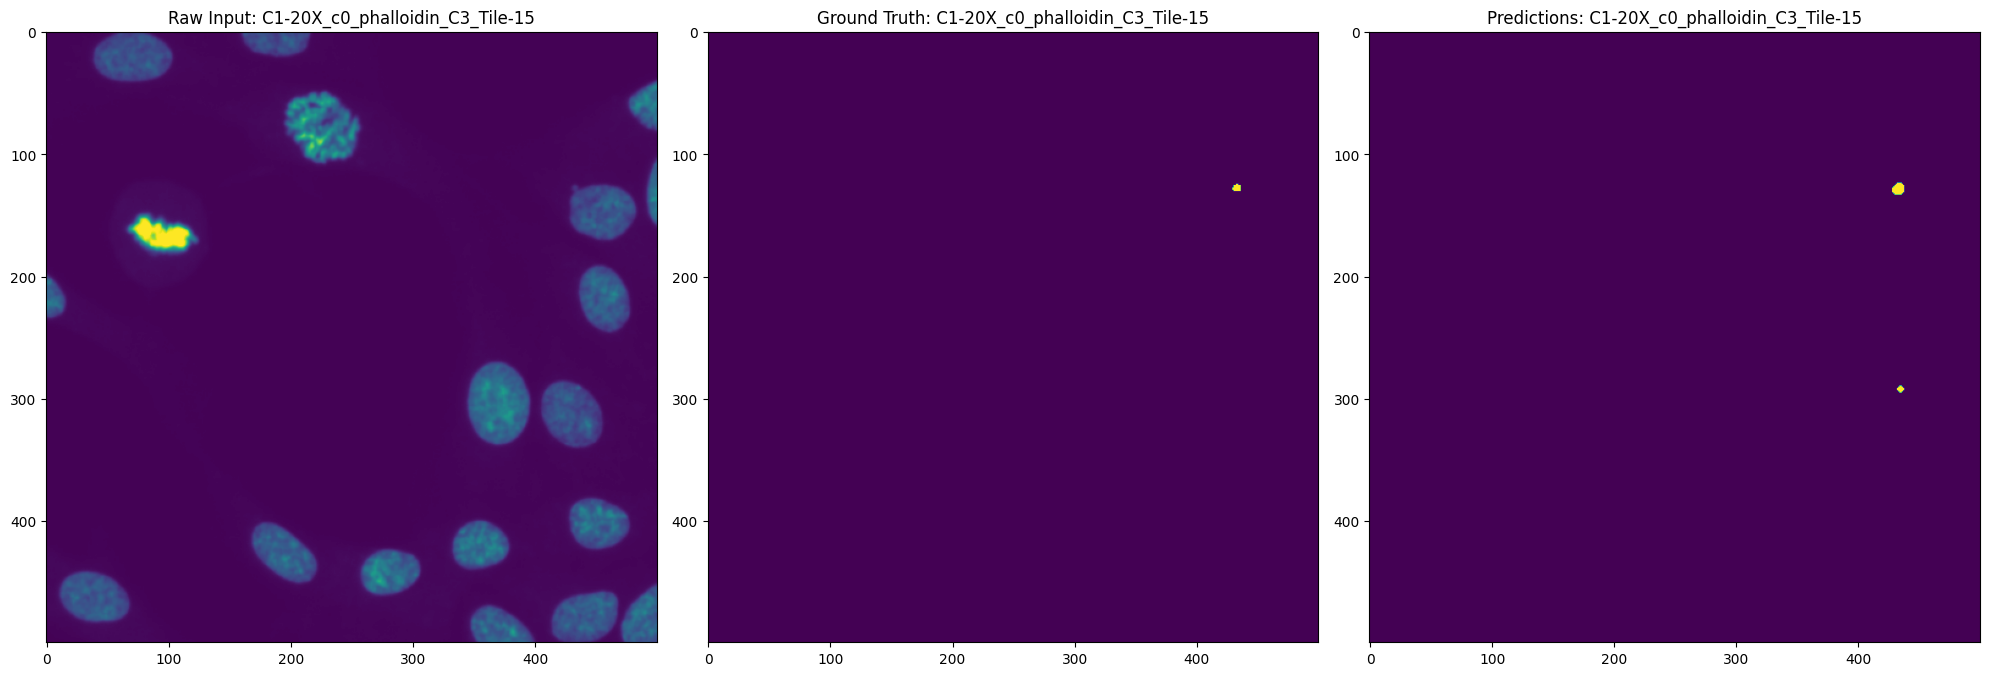

In [61]:
fig, ax = plt.subplots(1,3,figsize=(20,20))

row_start = 1500
row_end = 2000
column_start = 2000
column_end = 2500


ax[0].imshow(im[row_start:row_end, column_start:column_end])
ax[0].set_title(f'Raw Input: {imid}')

ax[1].imshow(mn_gt[row_start:row_end, column_start:column_end])
ax[1].set_title(f'Ground Truth: {imid}')

ax[2].imshow(mn_pred[row_start:row_end, column_start:column_end])
ax[2].set_title(f'Predictions: {imid}')

plt.tight_layout()
plt.show()

# Test learning rate scheduler

In [20]:
import sys
sys.path.append('../')
from microdet import detection
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
gpu = 3
device = f"cuda:{gpu}" if torch.cuda.is_available() else 'cpu'
model = detection.DetectionModel(device=device, finetune=True)

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer,T_max=20, eta_min=1e-6)
lrs = []
for epoch in range(20):
    print(f"Epoch: {epoch}, lr {optimizer.param_groups[0]['lr']}")
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

Epoch: 0, lr 1e-05
Epoch: 1, lr 9.938441702975689e-06
Epoch: 2, lr 9.755282581475769e-06
Epoch: 3, lr 9.45503262094184e-06
Epoch: 4, lr 9.045084971874738e-06
Epoch: 5, lr 8.535533905932739e-06
Epoch: 6, lr 7.938926261462368e-06
Epoch: 7, lr 7.269952498697736e-06
Epoch: 8, lr 6.5450849718747394e-06
Epoch: 9, lr 5.7821723252011565e-06
Epoch: 10, lr 5.000000000000001e-06
Epoch: 11, lr 4.217827674798848e-06
Epoch: 12, lr 3.454915028125264e-06
Epoch: 13, lr 2.7300475013022666e-06
Epoch: 14, lr 2.061073738537635e-06
Epoch: 15, lr 1.4644660940672626e-06
Epoch: 16, lr 9.549150281252633e-07
Epoch: 17, lr 5.449673790581611e-07
Epoch: 18, lr 2.447174185242324e-07
Epoch: 19, lr 6.155829702431172e-08


/scr/yren/miniconda3/envs/micronuclei_detection/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


<Axes: >

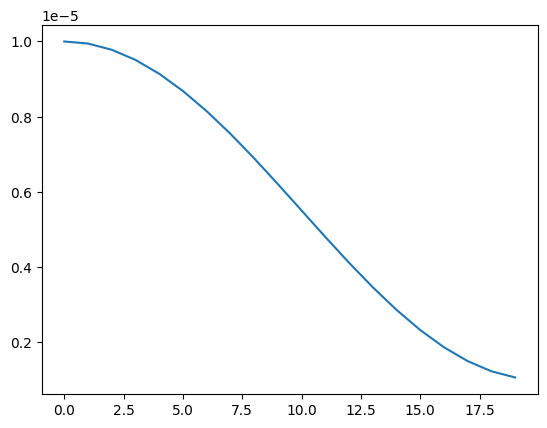

In [72]:
sns.lineplot(
    x=range(20),
    y=lrs
)

In [74]:
import os
files = os.listdir('/scr/yren/20241114_pilot_validation/20X_c0_HeLa')
files = [file for file in files if not file.startswith('.')]
files = [file for file in files if file.endswith('.tif')]
print(len(files))

1596


In [80]:
import skimage
import numpy as np

In [81]:
im = skimage.io.imread('/scr/yren/20241114_pilot_validation/20X_c0_HeLa/' + files[0])
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
print(im.shape)

(2720, 2720, 3)


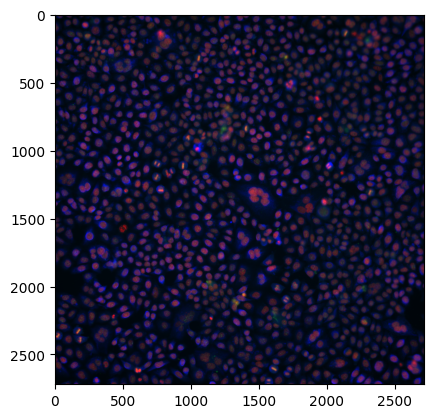

In [89]:
plt.imshow(im)

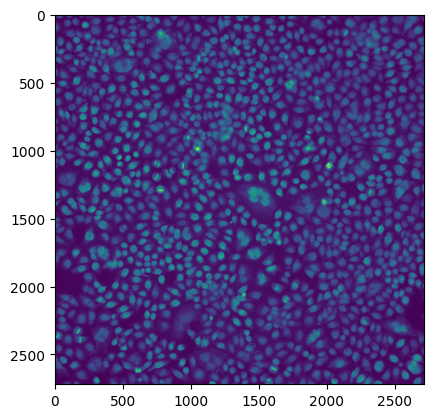

In [86]:
plt.imshow(np.mean(im, axis=2))

In [83]:
def patch_to_rgb(patch, edges=False):
    if edges:
        sobel = skimage.filters.sobel(patch)
        sobel = 2*skimage.exposure.rescale_intensity(sobel, out_range=np.float32)
        sobel[sobel > 1.] = 1.
    else:
        sobel = patch
        
    px = np.concatenate(
        (sobel[np.newaxis,:,:], patch[np.newaxis,:,:], patch[np.newaxis,:,:]), 
        axis=0)
    return torch.Tensor(px)

In [84]:
crop = patch_to_rgb(im, edges=True)

In [85]:
print(crop.shape)

torch.Size([3, 2720, 2720, 3])


In [87]:
im2 = skimage.io.imread('/scr/yren/20241114_pilot_validation/20X_c0_RPE/20X_c0_C6_Tile-9.phenotype.tif')
print(im2.shape)

(2720, 2720, 3)
